# Week 5: Customer Sales Analysis
This notebook handles the data loading, cleaning, merging, and visualization for week 5

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import os

print("Starting Customer Sales Analysis...")
# Create visualizations folder if it doesn't exist
os.makedirs('visualizations', exist_ok=True)

Starting Customer Sales Analysis...


In [16]:
try:
    df_sales = pd.read_csv("D:\Week5_Project\data\sales_data.csv")
    df_customers = pd.read_csv("D:\Week5_Project\data\customer_churn.csv")
    print("Datasets loaded successfully.")
except FileNotFoundError:
    print("Error: Files not found. Ensure both files exist in location")

Datasets loaded successfully.


In [17]:
# Cleaning IDs to extract just the numbers so they match
df_sales['CustNum'] = df_sales['Customer_ID'].str.replace('CUST', '').astype(int)
df_customers['CustNum'] = df_customers['CustomerID'].str.replace('C', '').astype(int)

# Format the dates
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_sales['Month'] = df_sales['Date'].dt.month
df_sales['Year'] = df_sales['Date'].dt.year

print("Data cleaned and dates formatted.")

Data cleaned and dates formatted.


In [18]:
#Merging the datasets on CustNum column
merged_df = pd.merge(df_sales, df_customers, on='CustNum', how='inner')
print(f"Datasets are merged successfully. Total records: {len(merged_df)}")

Datasets are merged successfully. Total records: 100


In [19]:
# Calculating core metrics
total_revenue = merged_df['Total_Sales'].sum()
total_customers = merged_df['CustNum'].nunique()
avg_order_value = merged_df['Total_Sales'].mean()

top_customers = merged_df.groupby('Customer_ID')['Total_Sales'].sum().sort_values(ascending=False)
top_cust_name = top_customers.index[0]
top_cust_val = top_customers.iloc[0]

# Creating Pivot Table
pivot_table = pd.pivot_table(merged_df, values='Total_Sales', index='Region', columns='Product', aggfunc='sum', fill_value=0)

# Filtering high-value loyal customers
high_value_loyal = merged_df[(merged_df['Total_Sales'] > 100000) & (merged_df['Tenure'] >= 12)]

print("\nQUICK METRICS:")
print(f"Total Revenue: Rs {total_revenue:,.2f}")
print(f"Average Order: Rs {avg_order_value:,.2f}")
print(f"Top Customer: {top_cust_name} (Rs {top_cust_val:,.2f})")

print("\nPIVOT TABLE (Sales by Region & Product):")
display(pivot_table)


QUICK METRICS:
Total Revenue: Rs 12,365,048.00
Average Order: Rs 123,650.48
Top Customer: CUST016 (Rs 373,932.00)

PIVOT TABLE (Sales by Region & Product):


Product,Headphones,Laptop,Monitor,Phone,Tablet
Region,,,,,
East,288361,221946,642870,506828,859634
North,107091,1798206,397100,489284,1191954
South,512168,1373120,39924,1471428,341212
West,476413,495938,268177,391854,491540



Generating Sales Dashboard...
Dashboard saved successfully in visualizations/executive_dashboard.png


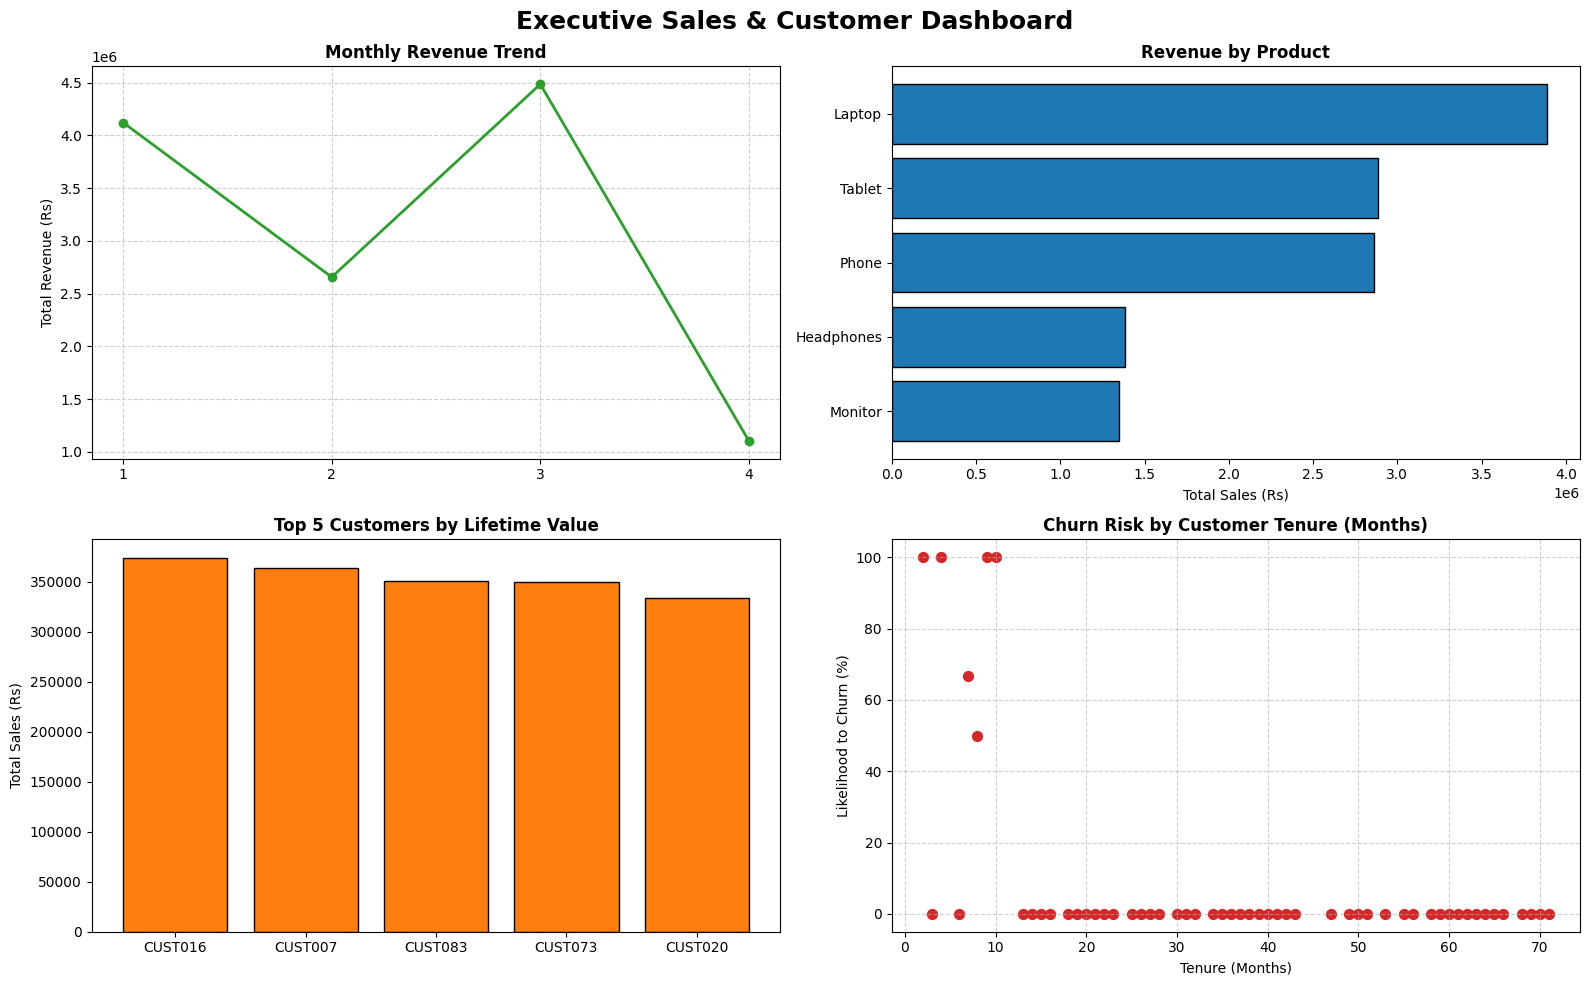

In [20]:
print("\nGenerating Sales Dashboard...")
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Executive Sales & Customer Dashboard', fontsize=18, fontweight='bold')

# Chart 1: Monthly Sales Trend
monthly_sales = merged_df.groupby('Month')['Total_Sales'].sum()
axs[0, 0].plot(monthly_sales.index, monthly_sales.values, marker='o', color='#2ca02c', linewidth=2)
axs[0, 0].set_title('Monthly Revenue Trend', fontweight='bold')
axs[0, 0].set_xticks(monthly_sales.index)
axs[0, 0].set_ylabel('Total Revenue (Rs)')
axs[0, 0].grid(linestyle='--', alpha=0.6)

# Chart 2: Revenue by Product
product_sales = merged_df.groupby('Product')['Total_Sales'].sum().sort_values()
axs[0, 1].barh(product_sales.index, product_sales.values, color='#1f77b4', edgecolor='black')
axs[0, 1].set_title('Revenue by Product', fontweight='bold')
axs[0, 1].set_xlabel('Total Sales (Rs)')

# Chart 3: Top 5 Customers
top_5 = top_customers.head(5)
axs[1, 0].bar(top_5.index, top_5.values, color='#ff7f0e', edgecolor='black')
axs[1, 0].set_title('Top 5 Customers by Lifetime Value', fontweight='bold')
axs[1, 0].set_ylabel('Total Sales (Rs)')

# Chart 4: Tenure vs Churn Rate
churn_by_tenure = merged_df.groupby('Tenure')['Churn'].mean() * 100
axs[1, 1].scatter(churn_by_tenure.index, churn_by_tenure.values, color='#d62728', s=50)
axs[1, 1].set_title('Churn Risk by Customer Tenure (Months)', fontweight='bold')
axs[1, 1].set_xlabel('Tenure (Months)')
axs[1, 1].set_ylabel('Likelihood to Churn (%)')
axs[1, 1].grid(linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('visualizations/executive_dashboard.png', dpi=300)
print("Dashboard saved successfully in visualizations/executive_dashboard.png")
plt.show()